# Markov modeller og Coalescent teori

Formålet med denne notebook er, at introducerer Markov modeller og coalescent teori. Målet er at nå hen og analysere bavian data, men inden jeg analyserer bavian data, vil jeg først forstå modellernes opbygning, og efter tilpasse det til bavian data. Så i denne notebook vil jeg komme ind på følgende:

1. **Coalescent modellen** — hvad er den, og hvad fortæller den.
2. **State space konstruktion** — hvordan repræsenterer man en populations state.
3. **Momenter og fordelinger** — forventet tid, varians, PDF og CDF
4. **Rewards** — hvordan man udtrækker information som Site Frequency Spectrum (SFS)
5. **Diskrete fordelinger** — modellering af mutationer
6. **Parameteriserede modeller** — modeller med forskellige parametre

Bavianer (*Papio-slægten*) udviser mønstre af hybridisering og migration. Ved at modellere, hvornår genetiske linjer mødes bagud i tid, kan jeg vise spor af disse historiske begivenheder som fx gamle admixture events eller indflydelse fra ghost-populationer (udødede populationer).

In [3]:
# Importer nødvendige pakker
# phasic skal altid importeres først for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, StateIndexer, PropertySet, Property, GraphCache,
    print_graph_cache_info, get_graph_cache_stats, set_log_level
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

# 1. Coalescentmodellen

Coalescent teorien beskriver hvordan genetiske linjer i en population coalescere sammen bagud i tid. Hvis man tager $n$ DNA-sekvenser fra nutiden og sporer dem tilbage, vil de på et tidspunkt mødes i en fælles forfader, som kaldes MRCA (*Most Recent Common Ancestor*). Den tid det tager for alle linjer at nå MRCA afhænger af populationens størrelse: jo større population, desto længere tid. Dette er måden, hvorpå jeg kan estimere populationsstørrelser fra genetiske data.

## State repræsentation
En state repræsenteres som en vektor, hvor:

 * Index $=$ antal efterkommere en lineage har ($1$-ton, $2$-ton, $3$-ton, osv.)
 * Værdi  antal lineages af den type

Eksempel med 4 prøver:

$(4,0,0,0) \rightarrow 4$ singletons (alle $4$ linjer er uafhængige). $(2,1,0,0) \rightarrow 2$ singletons $+1$ doubleton $(0,0,0,1) \rightarrow 1$ quadrupleton $=$ MRCA nået

En transition sker, når to lineages coalescer. Raten er proportional med antallet af mulige par, ligesom sandsynligheden for at to vilkårlige individer deler forfader afhænger af, hvor mange der er i populationen.


In [4]:
def coalescent_manual(nr_samples):
    """Bygger coalescent-grafen 'step-by-step'."""
    graph = Graph(nr_samples)                     # vektorlængde
    initial = np.zeros(nr_samples, dtype=int)
    initial[0] = nr_samples
    v = graph.find_or_create_vertex(initial)
    graph.starting_vertex().add_edge(v, 1)        

    idx = 1
    while idx < graph.vertices_length():
        vertex = graph.vertex_at(idx)
        state  = vertex.state()
        for i in range(nr_samples):
            for j in range(i, nr_samples):
                same = int(i == j)
                if same and state[i] < 2:
                    continue
                if not same and (state[i] < 1 or state[j] < 1):
                    continue
                new = state.copy()
                new[i] -= 1
                new[j] -= 1
                new[i + j + 1] += 1           
                child = graph.find_or_create_vertex(new)
                rate = state[i] * (state[j] - same) / (1 + same)
                vertex.add_edge(child, rate)
        idx += 1
    return graph

g_manual = coalescent_manual(4)
print(f'{g_manual.vertices_length()} vertices i den manuelle graf')

6 vertices i den manuelle graf


In [5]:
nr_samples = 4
labels = [f"{k+1}'ton" for k in range(nr_samples)]
states_df = pd.DataFrame(g_manual.states(), columns=labels)
states_df

,1'ton,2'ton,3'ton,4'ton
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


Jeg kan også bygge modellen via callback-funktion der returnerer mulige overgange fra en given state.

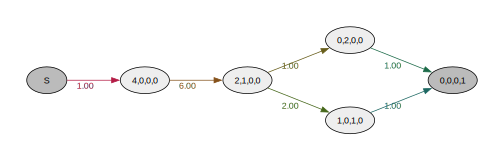

In [6]:
# Bygger coalescent-modellen med 4 prøver via en callback funktion.
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_model(state):
    transitions = []
    
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            
            # Behøver mindst 2 lineages af samme type (eller 1 af hver)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            
            # Ny state: to lineages med i+1 og j+1 efterkommere slår sig sammen til en med i+j+2 efterkommere
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            
            # Coalescence rate = antal mulige par
            rate = state[i] * (state[j] - same) / (1 + same)
            transitions.append([new, [rate]])
    
    return transitions

graph = Graph(coalescent_model)
graph.plot()

In [ ]:
graph.plot().render("output/coalescent_plot", format="png")

'output/coalescent_plot.png'

Grafen viser alle mulige states, som processen kan komme igennem. Startpunktet øverst til venstre er $(4,0,0,0)$ fire uafhængige singletons. Slutpunktet (*absorberende state*) nås, når den fjerde singleton er smeltet med de andre. Pilene repræsenterer mulige coalescence events, og raterne (tallene) bestemmer, hvor hurtigt man forventer at bevæge sig fra en state til den næste.

In [7]:
labels = [f"{i+1}'ton" for i in range(nr_samples)]

pd.DataFrame(graph.states(), columns=labels)

,1'ton,2'ton,3'ton,4'ton
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


# 2. Momenter og fordelinger 

## Forventet coalesceringstid
Når grafen er bygget, kan man beregne forventning og varians. Den forventede coalesceringstid svarer til den gennemsnitlige dybde af et træ. En stor forventning indikerer en stor effektiv populationsstørrelse ($N_e$) og/eller lang tid siden eventuelle splits. Dette er den størrelse jeg vil estimere for bavianerne.

In [8]:
# Beregn forventet tid til MRCA og varians
print(f"Forventet tid til MRCA:  {graph.expectation():.4f}")
print(f"Varians:                 {graph.variance():.4f}")

Forventet tid til MRCA:  1.5000
Varians:                 1.1389


## Sandsynlighedsfordelinger: PDF og CDF

Jeg kan også beregne hele sandsynlighedsfordelingen for coalesceringstiden:

- **PDF** (*Probability Density Function*): Hvor sandsynligt er det, at MRCA nås præcis ved tid $t$
- **CDF** (*Cumulative Distribution Function*): Hvad er sandsynligheden for, at MRCA er nået inden*tid $t$

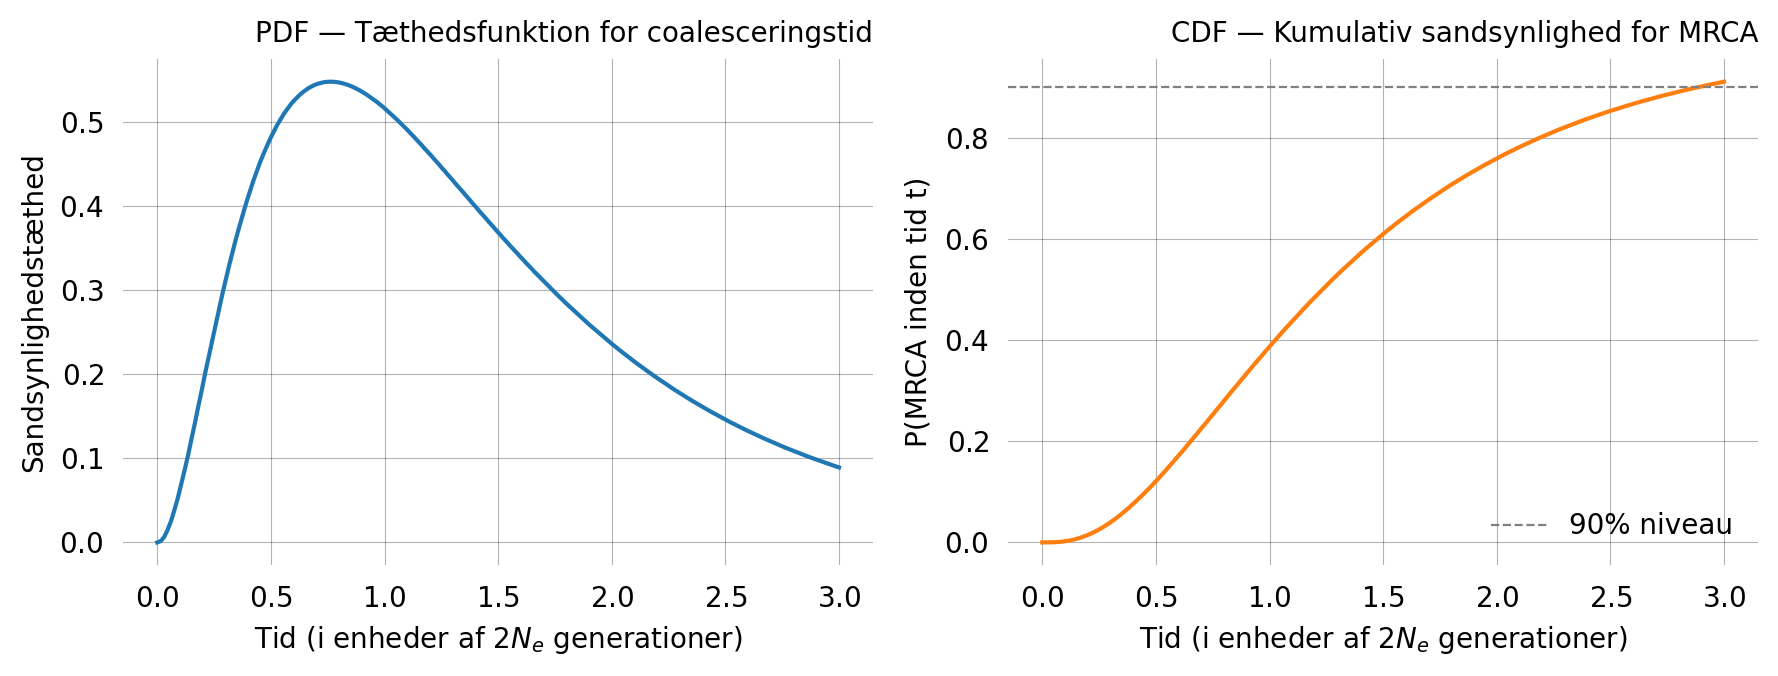

In [9]:
vals = np.linspace(0, 3, 200)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].plot(vals, graph.pdf(vals), color='C0')
axes[0].set_title("PDF — Tæthedsfunktion for coalesceringstid")
axes[0].set_xlabel("Tid (i enheder af $2N_e$ generationer)")
axes[0].set_ylabel("Sandsynlighedstæthed")

axes[1].plot(vals, graph.cdf(vals), color='C1')
axes[1].set_title("CDF — Kumulativ sandsynlighed for MRCA")
axes[1].set_xlabel("Tid (i enheder af $2N_e$ generationer)")
axes[1].set_ylabel("P(MRCA inden tid t)")
axes[1].axhline(0.9, ls='--', color='grey', lw=0.8, label='90% niveau')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
import os

path = os.path.expanduser(
    "output"
)
os.makedirs(path, exist_ok=True)

fig.savefig(f"{path}/coalescent_pdf_cdf.png", dpi=300, bbox_inches="tight")

## Expected sojourn time

*expected_sojourn_time* giver for hver transient state den forventede tid processen opholder sig der. Summen er $\mathbb E[T_\text{MRCA}]$.

In [9]:
graph.expected_sojourn_time()

[0.0,
 0.16666666666666663,
 0.33333333333333326,
 0.3333333333333333,
 0.6666666666666666,
 0.0]

## Simulering som validering

Jeg kan simulere samples fra modellen og sammenligne med de analytiske resultater. Så kan jeg teste om det simuleret gennemsnit stemmer overens med *graph.expectation()* det bør det og det er en god måde at tjekke, at modellen er implementeret korrekt.

Simuleret gennemsnit:   1.5108
Analytisk forventning:  1.5000
Forskel:                0.0108


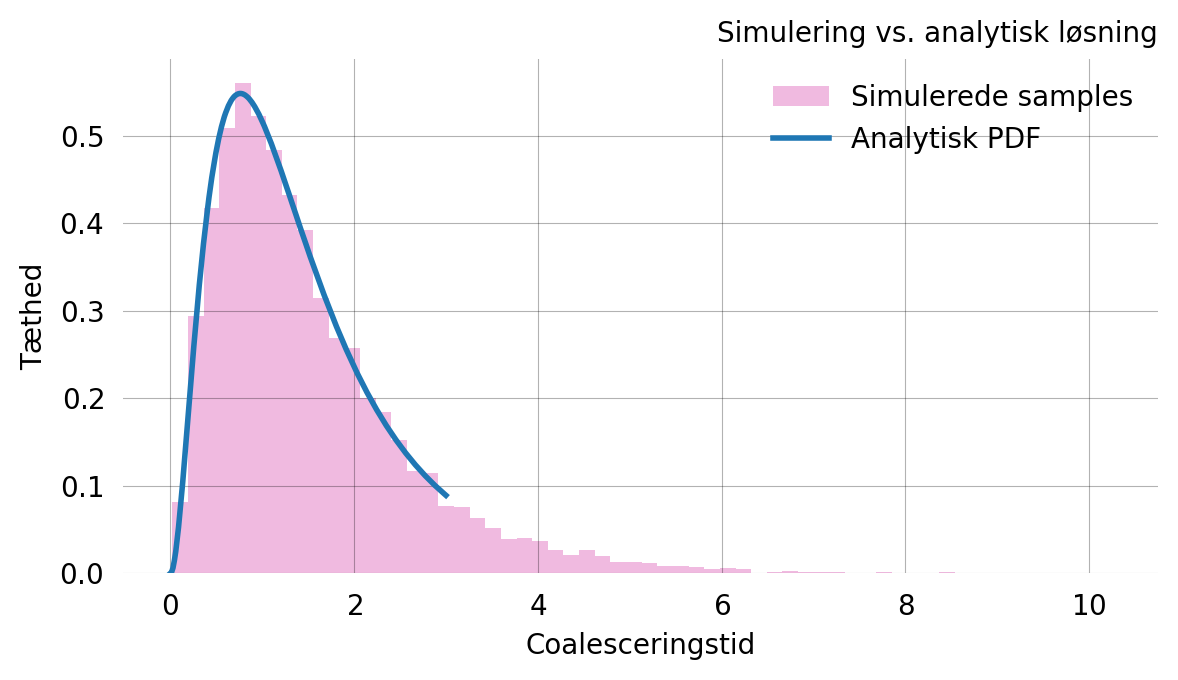

In [10]:
samples = graph.sample(10000)

print(f"Simuleret gennemsnit:   {np.mean(samples).item():.4f}")
print(f"Analytisk forventning:  {graph.expectation():.4f}")
print(f"Forskel:                {abs(np.mean(samples).item() - graph.expectation()):.4f}")

# Visualiser simulerede samples mod den analytiske PDF
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(samples, bins=60, density=True, alpha=0.5, label='Simulerede samples', color='C6')
ax.plot(vals, graph.pdf(vals), color='C0', lw=2, label='Analytisk PDF')
ax.set_xlabel("Coalesceringstid")
ax.set_ylabel("Tæthed")
ax.set_title("Simulering vs. analytisk løsning")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Rewards og Site Frequency Spectrum (SFS)

Reward er en funktion, der er baseret på, hvor meget tid processen tilbringer i en state. Dette giver mig mulighed for at beregne forventede værdier af størrelser.

En anvendelse er Site Frequency Spectrum (SFS): som er fordelingen af, hvor mange prøver der deler et mutationssted. En mutation, der opstår på en gren der fører til $k$ efterkommere, vil optræde i $k$ prøver og bidrage til SFS som en $k$-ton.

Ideen er, at den forventede mængde tid, modellen tilbringer i state med $k$-ton lineages, er proportional med antallet af $k$-ton varianter jeg forventer at observere.

In [16]:
# Genbyg grafen og beregn reward-matrixen
# Hver søjle i reward_matrix svarer til en state 
# Hver række svarer til en type lineage (singleton, doubleton, osv.)

graph = Graph(coalescent_model)
reward_matrix = graph.states().T

print(f"Reward-matrixens form: {reward_matrix.shape}")
print(f"  → {reward_matrix.shape[0]} typer lineages × {reward_matrix.shape[1]} state i grafen")
print()
print("Reward-vektor for singletons (1-tons):")
print(reward_matrix[0])
print()
print("Reward-vektor for doubletons (2-tons):")
print(reward_matrix[1])
print("Reward-vektor for tribletons (3-tons):")
print(reward_matrix[2])
print("Reward-vektor for quadrupleton (4-tons):")
print(reward_matrix[3])

Reward-matrixens form: (4, 6)
  → 4 typer lineages × 6 state i grafen

Reward-vektor for singletons (1-tons):
[0 4 2 0 1 0]

Reward-vektor for doubletons (2-tons):
[0 0 1 2 0 0]
Reward-vektor for tribletons (3-tons):
[0 0 0 0 1 0]
Reward-vektor for quadrupleton (4-tons):
[0 0 0 0 0 1]


Forventet SFS (proportional med antal forventede varianter):
  1'ton: 2.0000
  2'ton: 1.0000
  3'ton: 0.6667
  4'ton: 0.0000


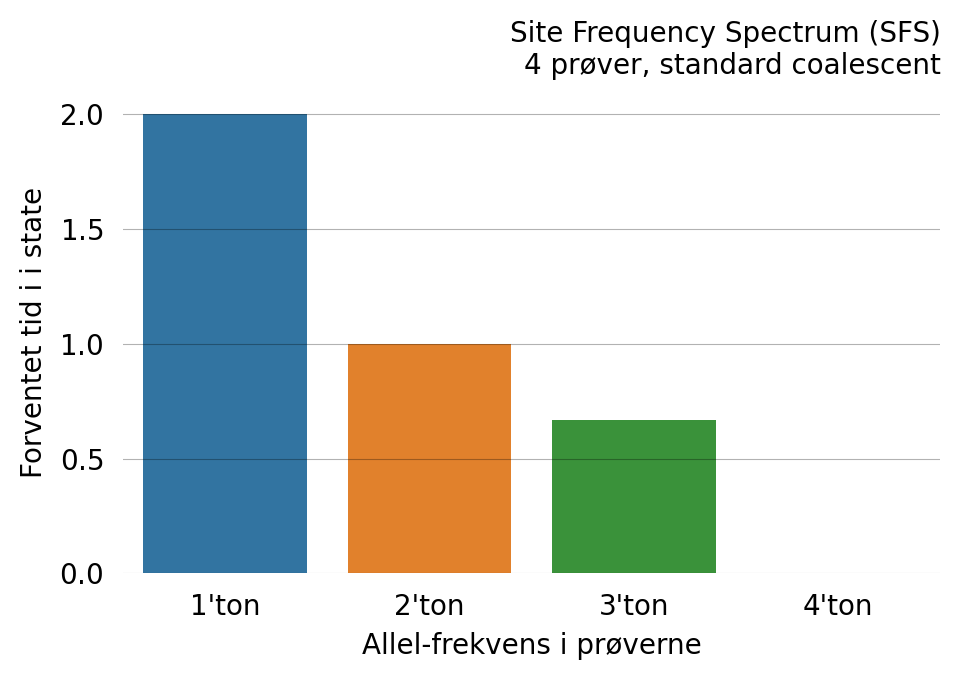

In [17]:
# Beregn det forventede SFS 
# graph.expectation(rewards) giver forventet tid vægtet med rewards
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[0])]
sfs = [graph.expectation(r) for r in reward_matrix]

print("Forventet SFS (proportional med antal forventede varianter):")
for label, val in zip(labels, sfs):
    print(f"  {label}: {val:.4f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=labels, y=sfs, hue=labels, ax=ax, legend=False)
ax.set_title("Site Frequency Spectrum (SFS)\n4 prøver, standard coalescent")
ax.set_xlabel("Allel-frekvens i prøverne")
ax.set_ylabel("Forventet tid i i state")
plt.tight_layout()
plt.show()

In [18]:
path = os.path.expanduser(
    "~/emma_giraf/people/emmachristensen/emma-giraf/thesis/illustrations"
)
os.makedirs(path, exist_ok=True)

fig.savefig(f"{path}/sfs_plot.png", dpi=300, bbox_inches="tight")

4-ton-elementet er 0 fordi 4-ton er den absorberende state (MRCA), den eksisterer i et øjeblik og bidrager ikke til branch-længde. 

## Reward-transformationer og fordelinger per type 

Det er nu muligt, at beregne hele fordelingen af tid brugt på fx doubletons. Dette giver ikke bare forventningen, men hele sandsynlighedsfordelingen, hvilket er nyttigt for at kvantificere usikkerhed.

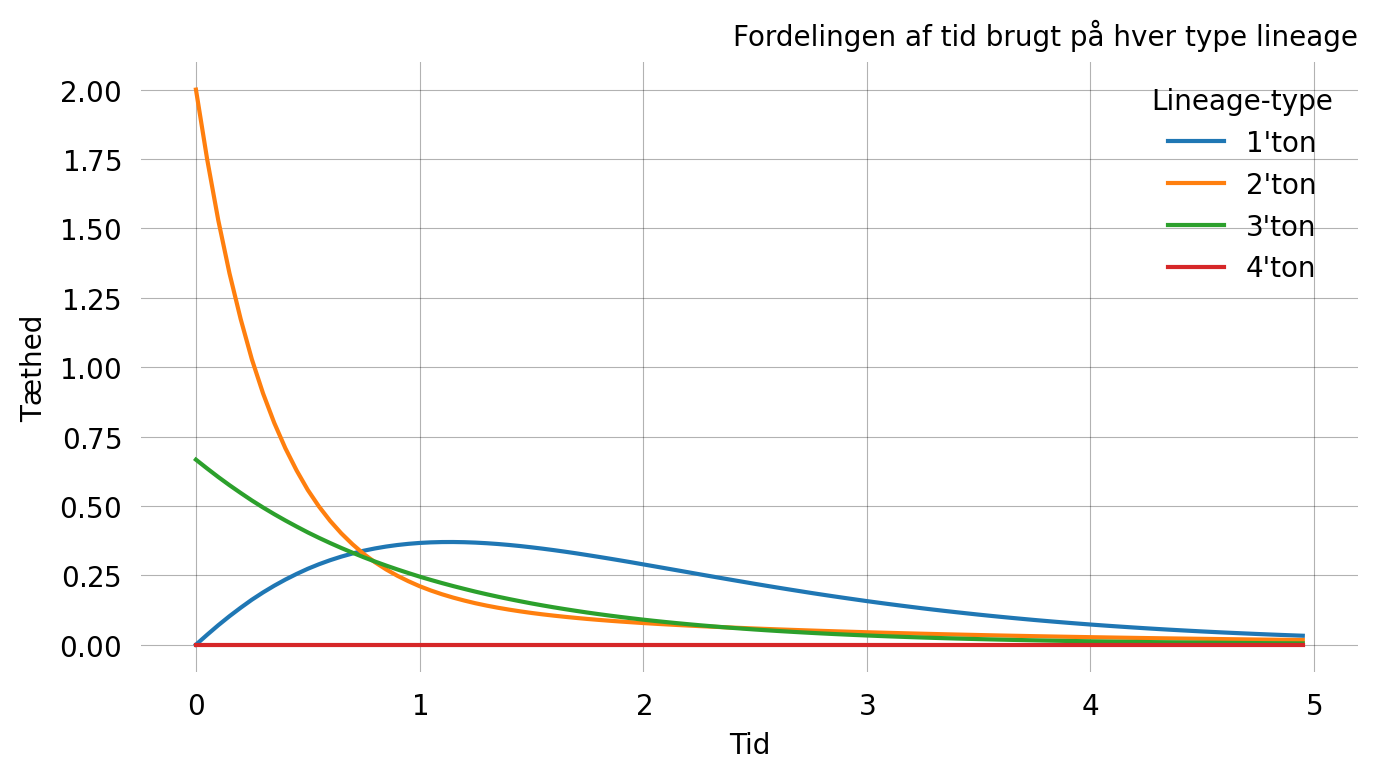

In [19]:
# Reward-transform: jeg laver en ny graf, der kun tæller tid brugt på lineages af en bestemt type
times = np.arange(0, 5, 0.05)

fig, ax = plt.subplots(figsize=(7, 4))
for i, rewards in enumerate(reward_matrix):
    rt_graph = graph.reward_transform(rewards)
    ax.plot(times, rt_graph.pdf(times), label=labels[i])

ax.set_xlabel("Tid")
ax.set_ylabel("Tæthed")
ax.set_title("Fordelingen af tid brugt på hver type lineage")
ax.legend(title="Lineage-type")
plt.tight_layout()
plt.show()

In [20]:
path = os.path.expanduser(
    "~/emma_giraf/people/emmachristensen/emma-giraf/thesis/illustrations"
)
os.makedirs(path, exist_ok=True)

fig.savefig(f"{path}/reward_plot.png", dpi=300, bbox_inches="tight")

## 4. Diskrete fordelinger og mutationer

Indtil nu har jeg arbejdet med kontinuert tid (coalesceringstid). Men i genetiske data observerer man diskrete *antal mutationer*, ikke kontinuerte tider.

Forbindelsen er mutationsraten $\mu$: Givet en gren af varighed $t$, forventer man $\mu \cdot t$ mutationer. Phasic håndterer dette ved at *diskretisere* modellen: jeg tilføjer en hjælpe state, der samler mutationer, som de opstår langs grenene. Dette er vigtigt, fordi det er antal mutationer jeg faktisk kan tælle i bavian-genomet.

In [14]:
@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent(state):
    """Standard coalescent model til brug med diskretisering."""
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
    return transitions

mutation_graph = Graph(coalescent)

# Mutationsraten: forventet antal mutationer per tidsenhed per lineage
mutation_rate = 0.1

def mutation(state: np.ndarray, mutation_rate: float):
    """Antal aktive lineages × rate = total mutationsrate i denne tilstand."""
    nr_lineages = sum(state)
    return nr_lineages * mutation_rate

# Diskretiser: tilføj hjælpe state der samler mutationer
rewards = mutation_graph.discretize(mutation, mutation_rate=mutation_rate)

print(f"Forventet antal mutationer (analytisk): {mutation_graph.expectation(rewards):.4f}")
print(f"\nValidering via total grenvarighed × rate:")
base_graph = Graph(coalescent)
tot_brlen = base_graph.expectation(base_graph.states().T.sum(axis=0))
print(f"  Total grenvarighed × μ = {tot_brlen:.4f} × {mutation_rate} = {tot_brlen * mutation_rate:.4f}")

Forventet antal mutationer (analytisk): 0.3667

Validering via total grenvarighed × rate:
  Total grenvarighed × μ = 3.6667 × 0.1 = 0.3667


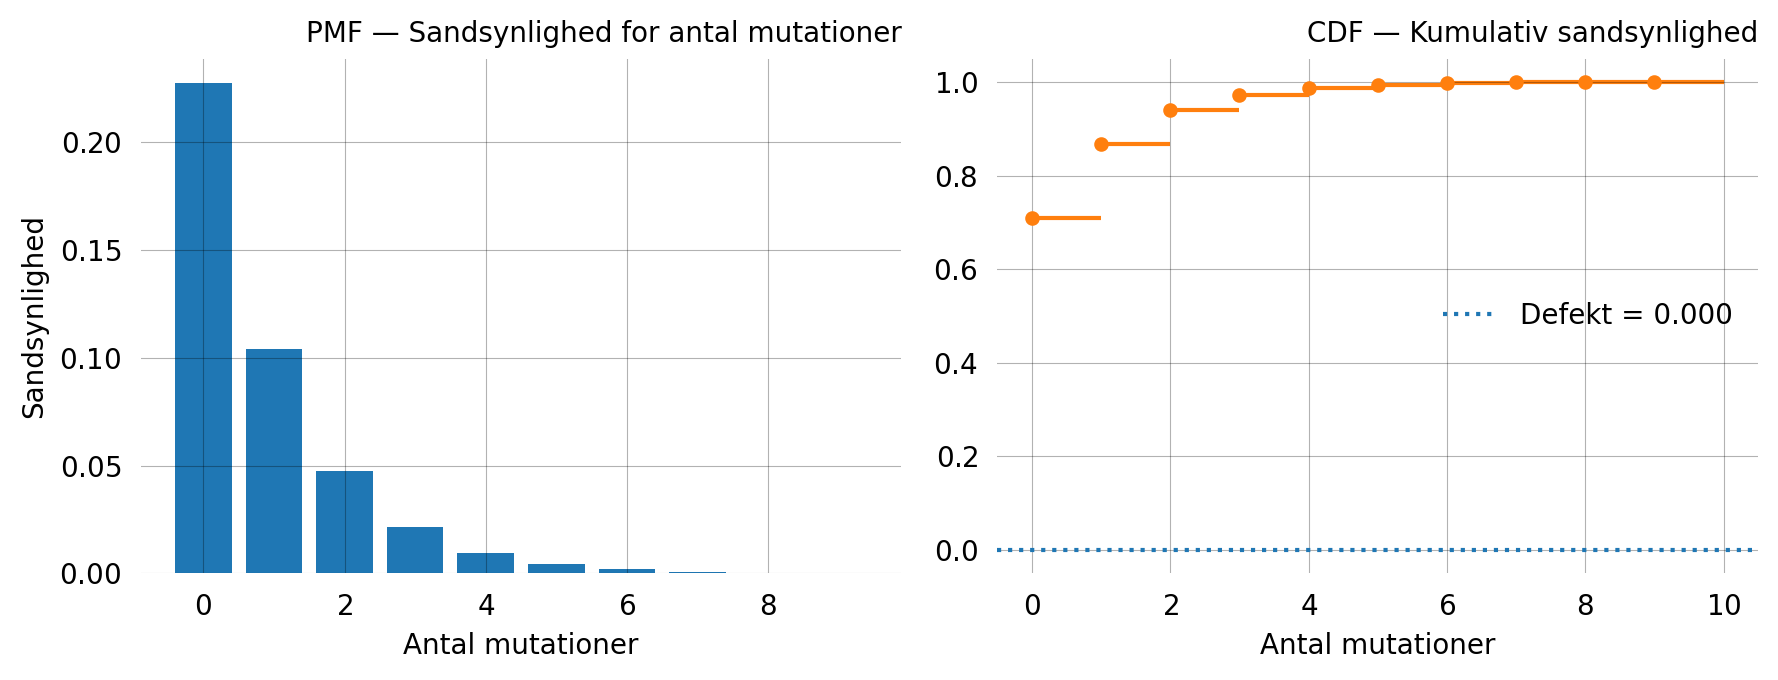

In [15]:
# Visualiser fordelingen af antal mutationer (PMF og CDF)
rt_mut_graph = mutation_graph.reward_transform_discrete(rewards)

mutations = np.arange(10)
pmf = rt_mut_graph.pdf(mutations)
cdf = rt_mut_graph.cdf(mutations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

ax1.bar(mutations, pmf, color='C0')
ax1.set_title("PMF — Sandsynlighed for antal mutationer")
ax1.set_xlabel("Antal mutationer")
ax1.set_ylabel("Sandsynlighed")

left, right = mutations, np.arange(1, mutations.size + 1)
ax2.hlines(y=cdf, xmin=left, xmax=right, zorder=1, color='C1')
ax2.scatter(left, cdf, s=18, zorder=2, color='C1')
ax2.axhline(y=mutation_graph.defect(), linestyle='dotted', 
            label=f'Defekt = {mutation_graph.defect():.3f}')
ax2.set_title("CDF — Kumulativ sandsynlighed")
ax2.set_xlabel("Antal mutationer")
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Parametriserede modeller

Jeg har indtil nu arbejdet med en model med faste rater. Men i praksis vil jeg estimere parametre, fx den effektive populationsstørrelse $N_e$ og rekombinationsraten $R$.

Phasic understøtter dette via parameteriserede modeller, hvor overgangsraterne udtrykkes som lineær kombinationer af parametre. En coalescence rate på $\frac{1}{N_e}$ og en rekombinationsrate $R$ kan begge variere, og jeg kan beregne momenter og fordelinger for alle kombinationer.
Dette danner grundlaget for inferens i den næste notebook 02.

In [16]:
# To-locus ARG: modellerer to genetiske loci med rekombination imellem dem
# Parameter 1: coalescence-rate = 1/N
# Parameter 2: rekombinationsrate R
from phasic.state_indexing import StateIndexer, Property

nr_samples = 4
indexer = StateIndexer(
    n_descendants=[
        Property('locus1', max_value=nr_samples),
        Property('locus2', max_value=nr_samples)
    ]
)

initial = [0] * indexer.state_length
initial[indexer.props_to_index(locus1=1, locus2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg(state, indexer=None, N=None, R=None):
    """To-locus ARG med coalescence-rate 1/N og rekombinationsrate R."""
    transitions = []
    if state.sum() <= 1:
        return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.n_descendants.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            props_j = indexer.n_descendants.index_to_props(j)

            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            locus1 = props_i.locus1 + props_j.locus1
            locus2 = props_i.locus2 + props_j.locus2
            if locus1 <= nr_samples and locus2 <= nr_samples:
                child[indexer.props_to_index(locus1=locus1, locus2=locus2)] += 1
                # Rate-koefficient [1/N, 0]: coalescence skalerer med 1/N
                transitions.append([child, [state[i] * (state[j] - same) / (1 + same), 0]])

        # Rekombination: en lineage splitter op i to (en per locus)
        if state[i] > 0 and props_i.locus1 > 0 and props_i.locus2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.props_to_index(locus1=props_i.locus1, locus2=0)] += 1
            child[indexer.props_to_index(locus1=0, locus2=props_i.locus2)] += 1
            # Rate-koefficient [0, 1]: rekombination skalerer kun med R
            transitions.append([child, [0, 1]])

    return transitions

# Bygger grafen raterne er nu parameteriserede
graph = Graph(two_locus_arg, N=1, R=1, indexer=indexer)
print(f"Antal parametre i modellen: {graph.param_length()}")
print(f"  Parameter 1: coalescence-rate (≈ 1/N_e)")
print(f"  Parameter 2: rekombinationsrate (R)")

Antal parametre i modellen: 2
  Parameter 1: coalescence-rate (≈ 1/N_e)
  Parameter 2: rekombinationsrate (R)


In [17]:
# Undersøger hvordan N og R påvirker den forventede TMRCA
# - Stor N $\rightarrow$ lang forventet tid (stor population = langsom coalescence)
# - Stor R $\rightarrow$ kortere forventet tid (rekombination bryder linjer op)

print(f"{'N':<6} {'R':<6} {'E[TMRCA]':<12} {'Var[TMRCA]':<12}")
print("-" * 38)

N_values = [1, 1, 1.5, 1.5, 2, 2]
R_values = [1, 2,   1,   2, 1, 2]

for N, R in zip(N_values, R_values):
    graph.update_weights([1/N, R])
    print(f"{N:<6} {R:<6} {graph.expectation():<12.4f} {graph.variance():<12.4f}")

N      R      E[TMRCA]     Var[TMRCA]  
--------------------------------------
1      1      2.0089       2.0642      
1      2      2.2946       2.3296      
1.5    1      3.2561       5.0344      
1.5    2      3.7028       5.4035      
2      1      4.5892       9.3184      
2      2      5.1651       9.6593      


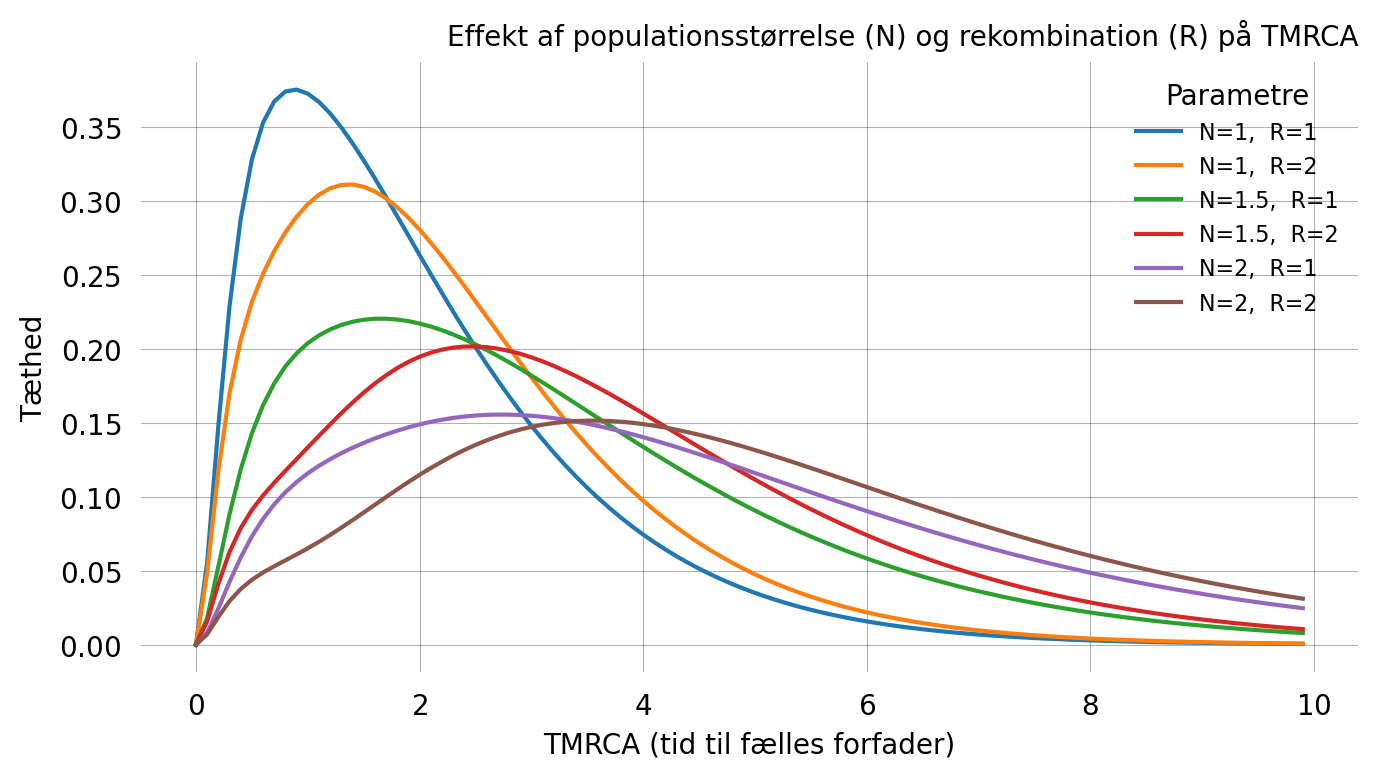

In [18]:
# Visualiser PDF for alle kombinationer af N og R
x = np.arange(0, 10, 0.1)

fig, ax = plt.subplots(figsize=(7, 4))
for N, R in zip(N_values, R_values):
    graph.update_weights([1/N, R])
    ax.plot(x, graph.pdf(x), label=f'N={N},  R={R}')

ax.set_xlabel("TMRCA (tid til fælles forfader)")
ax.set_ylabel("Tæthed")
ax.set_title("Effekt af populationsstørrelse (N) og rekombination (R) på TMRCA")
ax.legend(title="Parametre", fontsize=8)
plt.tight_layout()
plt.show()

Plottet illustrerer at større $N$ og højere $R$ skubber fordelingen mod kortere tider, fordi rekombination bryder linjer op i separate historier, og store populationer konvergerer hurtigere i relative tidsenheder.

I Notebook 02 introducerer jeg inferens: givet observerede data, hvordan estimerer man de biologiske parametre. Jeg arbejder med Method of Moments og Bayesiansk inferens via SVGD, stadig på simulerede data, inden jeg anvender det på bavian data.